<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto final de aprendizaje automático**

**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Autores:** Anais Aponte, Balam Castro, Cristina Cerverón 

</div>

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Trabajo geoespacial
import geopandas as gpd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Cargamos el dataset final procesado generado en el notebook 01_build_dataset.ipynb.
df_bcn = pd.read_csv('../data/processed/dataset_final.csv')

In [3]:
# ============================================================
# PRIMERA VISUALIZACIÓN DEL DATASET
# ============================================================

# Mostramos una muestra aleatoria de registros para revisar rápidamente la estructura general del dataset.
df_bcn.sample(10)

,system:index_x,blue,bsi,fecha,green,latitude_x,longitude_x,mndwi,month_x,nbr,...,system:index_y,latitude_y,longitude_y,lst_day_c,lst_night_c,month_y,occurrence_y,year_y,.geo_y,elevation
27628,1_896_0_0,0.03830,-0.295311,2020-05-01,0.07030,41.458104,2.215380,-0.484604,5.0,0.552855,...,1_896_0_0,41.458104,2.215380,30.203333,17.096667,5.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",108
57562,2_1199_0_0,0.02235,-0.136408,2024-09-01,0.03735,41.498258,2.235323,-0.601281,9.0,0.462410,...,2_1199_0_0,41.498258,2.235323,23.110000,16.380000,9.0,0,2024,"{""type"":""MultiPoint"",""coordinates"":[]}",267
14034,2_108_0_0,0.15130,0.114338,2024-03-01,0.17300,41.357582,2.169297,-0.228109,3.0,-0.061815,...,2_108_0_0,41.357582,2.169297,18.780000,11.280000,3.0,0,2024,"{""type"":""MultiPoint"",""coordinates"":[]}",4
46602,0_1211_0_0,0.04655,0.064937,2023-10-01,0.07245,41.473734,2.101115,-0.547046,10.0,0.191954,...,0_1211_0_0,41.473734,2.101115,22.003333,15.683333,10.0,0,2023,"{""type"":""MultiPoint"",""coordinates"":[]}",108
32070,0_145_0_0,0.14360,0.163598,2022-10-01,0.16860,41.354348,2.100845,-0.289657,10.0,-0.164363,...,0_145_0_0,41.354348,2.100845,26.470000,17.910000,10.0,0,2022,"{""type"":""MultiPoint"",""coordinates"":[]}",17
27741,1_1050_0_0,0.02770,-0.294985,2020-05-01,0.05190,41.423608,2.112433,-0.466049,5.0,0.627750,...,1_1050_0_0,41.423608,2.112433,24.263333,15.943333,5.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",375
20671,2_1041_0_0,0.10380,0.134021,2025-06-01,0.12320,41.486940,2.049641,-0.260726,6.0,-0.083500,...,2_1041_0_0,41.486940,2.049641,36.800000,24.503333,6.0,0,2025,"{""type"":""MultiPoint"",""coordinates"":[]}",148
29593,0_847_0_0,0.04980,-0.048080,2020-01-01,0.08360,41.497719,2.173878,-0.437416,1.0,0.355347,...,0_847_0_0,41.497719,2.173878,12.900000,4.565000,1.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",59
7666,1_988_0_0,0.08525,0.089098,2020-08-01,0.11620,41.419566,2.184119,-0.403873,8.0,0.070423,...,1_988_0_0,41.419566,2.184119,33.350000,24.395000,8.0,0,2020,"{""type"":""MultiPoint"",""coordinates"":[]}",38
68584,1_1278_0_0,0.04840,-0.005201,2022-08-01,0.07860,41.410942,2.028620,-0.498004,8.0,0.260820,...,1_1278_0_0,41.410942,2.028620,35.415000,23.015000,8.0,0,2022,"{""type"":""MultiPoint"",""coordinates"":[]}",119


In [4]:
# ============================================================
# REVISIÓN DE COLUMNAS
# ============================================================

# Mostramos todas las columnas completas del dataset.
df_bcn.columns

Index(['system:index_x', 'blue', 'bsi', 'fecha', 'green', 'latitude_x',
       'longitude_x', 'mndwi', 'month_x', 'nbr', 'ndbi', 'ndmi', 'ndvi',
       'ndwi', 'nir', 'occurrence_x', 'point_id', 'red', 'savi', 'swir1',
       'swir2', 'year_x', '.geo_x', 'system:index_y', 'latitude_y',
       'longitude_y', 'lst_day_c', 'lst_night_c', 'month_y', 'occurrence_y',
       'year_y', '.geo_y', 'elevation'],
      dtype='str')

In [5]:
# ============================================================
# LIMPIEZA DE COLUMNAS
# ============================================================

# Eliminamos columnas técnicas y duplicadas tras el merge.
cols_drop = [
    'system:index_x', 'system:index_y',
    '.geo_x', '.geo_y',
    'occurrence_x', 'occurrence_y',
    'latitude_y', 'longitude_y',
    'month_y', 'year_y',
    'red', 'green', 'blue'
]

df_bcn = df_bcn.drop(
    columns=[c for c in cols_drop if c in df_bcn.columns]
)

In [6]:
# ============================================================
# RENOMBRE DE COLUMNAS
# ============================================================

# Renombramos columnas para dejar nombres más limpios y consistentes.
df_bcn = df_bcn.rename(columns={
    'latitude_x': 'latitude',
    'longitude_x': 'longitude',
    'month_x': 'month',
    'year_x': 'year'
})

In [7]:
# ============================================================
# FORMATO DE FECHA
# ============================================================

# Renombramos la columna fecha 
df_bcn = df_bcn.rename(columns={'fecha': 'date'})

# La convertimos a datetime.
df_bcn['date'] = pd.to_datetime(df_bcn['date'])

In [8]:
# ============================================================
# REORDENAR COLUMNAS
# ============================================================

# Reordenamos columnas principales para facilitar la lectura del dataset.
cols_first = [
    'point_id',
    'date',
    'latitude',
    'longitude',
    'elevation',
    'month',
    'year'
]

cols_first = [c for c in cols_first if c in df_bcn.columns]

cols_rest = [c for c in df_bcn.columns if c not in cols_first]

df_bcn = df_bcn[cols_first + cols_rest]

# Visualizamos las primeras filas tras reorganizar las columnas.
df_bcn.head()

,point_id,date,latitude,longitude,elevation,month,year,bsi,mndwi,nbr,ndbi,ndmi,ndvi,ndwi,nir,savi,swir1,swir2,lst_day_c,lst_night_c
0,0.0,2020-10-01,41.438161,2.099767,301,10.0,2020,-0.312553,-0.542042,0.674365,-0.358526,0.358526,0.838158,-0.754032,0.2175,1.256971,0.10270,0.04230,18.125,10.965
1,1.0,2020-10-01,41.455948,2.191665,27,10.0,2020,0.106304,-0.317261,0.018942,0.069360,-0.069360,0.212814,-0.253480,0.2972,0.319188,0.34150,0.28615,20.825,12.565
2,2.0,2020-10-01,41.376447,2.102462,85,10.0,2020,0.061652,-0.350239,0.054307,0.005074,-0.005074,0.299576,-0.345779,0.2451,0.449304,0.24760,0.21985,21.685,12.930
3,3.0,2020-10-01,41.396659,2.139652,92,10.0,2020,0.084935,-0.121158,-0.036384,0.116056,-0.116056,0.017166,-0.005175,0.0874,0.025742,0.11035,0.09400,21.835,14.425
4,4.0,2020-10-01,41.368093,2.043173,15,10.0,2020,0.061221,-0.362908,0.189122,-0.056646,0.056646,0.300055,-0.411103,0.2383,0.450020,0.21275,0.16250,23.155,11.635


In [9]:
# ============================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================

# Revisamos tipos de datos, valores nulos y memoria utilizada.
df_bcn.info()

<class 'pandas.DataFrame'>
RangeIndex: 69683 entries, 0 to 69682
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   point_id     69683 non-null  float64       
 1   date         69683 non-null  datetime64[us]
 2   latitude     69683 non-null  float64       
 3   longitude    69683 non-null  float64       
 4   elevation    69683 non-null  int64         
 5   month        69683 non-null  float64       
 6   year         69683 non-null  int64         
 7   bsi          69683 non-null  float64       
 8   mndwi        69683 non-null  float64       
 9   nbr          69683 non-null  float64       
 10  ndbi         69683 non-null  float64       
 11  ndmi         69683 non-null  float64       
 12  ndvi         69683 non-null  float64       
 13  ndwi         69683 non-null  float64       
 14  nir          69683 non-null  float64       
 15  savi         69683 non-null  float64       
 16  swir1        69

In [10]:
# ============================================================
# DIMENSIONES DEL DATASET
# ============================================================

# Revisamos el número de filas y columnas del dataset.
df_bcn.shape

(69683, 20)

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

El dataset actual contiene la información base obtenida tras integrar datos de Sentinel-2, MODIS y elevación del terreno para los mismos puntos geográficos sobre Barcelona.

Tras el proceso de limpieza y organización, el dataset cuenta con **69,683 registros y 20 variables** relacionadas con información espacial, temporal, espectral y térmica.

A partir de esta base se crearán nuevas variables derivadas que permitan representar mejor el fenómeno Urban Heat Island (UHI), incluyendo anomalías térmicas diurnas y nocturnas, amplitud térmica, estaciones del año y la variable objetivo de riesgo UHI.

</div>

In [ ]:
# ============================================================
# ANOMALÍA TÉRMICA DIURNA
# ============================================================

# Calculamos cuánto se desvía la temperatura diurna respecto a la media del mismo mes.
# Valores positivos indican zonas más calientes de lo normal.

df_bcn['lst_day_anomaly'] = (
    df_bcn['lst_day_c'] - df_bcn.groupby('month')['lst_day_c'].transform('mean')
)

In [ ]:
# ============================================================
# ANOMALÍA TÉRMICA NOCTURNA
# ============================================================

# Calculamos cuánto se desvía la temperatura nocturna respecto a la media mensual.
# Esto es especialmente útil para detectar Urban Heat Islands, ya que las ciudades suelen mantenerse más calientes por la noche.

df_bcn['lst_night_anomaly'] = (
    df_bcn['lst_night_c'] - df_bcn.groupby('month')['lst_night_c'].transform('mean')
)

In [13]:
# ============================================================
# AMPLITUD TÉRMICA
# ============================================================

# Calculamos la diferencia entre la temperatura diurna y nocturna.
# Esta variable ayuda a detectar zonas urbanas que retienen calor durante la noche, fenómeno típico de las Urban Heat Islands (UHI).

df_bcn['thermal_amplitude'] = (
    df_bcn['lst_day_c'] - df_bcn['lst_night_c']
)

In [19]:
# ============================================================
# ESTACIÓN DEL AÑO
# ============================================================

# Creamos una variable categórica de estación del año a partir del mes correspondiente a cada registro.

def get_season(month):

    if month in [12, 1, 2]:
        return 'winter'

    elif month in [3, 4, 5]:
        return 'spring'

    elif month in [6, 7, 8]:
        return 'summer'

    else:
        return 'autumn'

df_bcn['season'] = df_bcn['month'].apply(get_season)

# Verificamos resultado
df_bcn['season'].value_counts()

season
winter    17946
summer    17946
spring    17034
autumn    16757
Name: count, dtype: int64

In [20]:
# ============================================================
# VARIABLE OBJETIVO: RIESGO UHI
# ============================================================

# Creamos una variable objetivo binaria de riesgo UHI utilizando la anomalía térmica nocturna (lst_night_anomaly).
#
# Se considera que existe riesgo UHI cuando la anomalía térmica nocturna es positiva, es decir, cuando la temperatura nocturna
# del punto está por encima de la media mensual.
#
# Esto tiene sentido físico porque el fenómeno Urban Heat Island se manifiesta especialmente durante la noche, momento en el que
# las superficies urbanas retienen calor y las diferencias urbano/rural se vuelven más evidentes.
#
# Clasificación utilizada:
#
# - 0 → no risk:
#       anomalía térmica nocturna <= 0
#
# - 1 → risk:
#       anomalía térmica nocturna > 0
#
# Además, esta simplificación binaria:
#
# - facilita la interpretación del modelo,
# - simplifica el problema de clasificación,
# - y mejora la claridad en la evaluación del rendimiento predictivo.

df_bcn['uhi_risk'] = (
    df_bcn['lst_night_anomaly'] > 0
).astype(int)

# Verificamos distribución de clases
df_bcn['uhi_risk'].value_counts()

uhi_risk
1    36621
0    33062
Name: count, dtype: int64

In [22]:
# ============================================================
# DIMENSIONES FINALES DEL DATASET
# ============================================================

# Verificamos el número final de filas y columnas tras el proceso de feature engineering.
df_bcn.shape

(69683, 25)

In [23]:
# ============================================================
# INFORMACIÓN FINAL DEL DATASET
# ============================================================

# Revisamos tipos de datos, valores nulos y memoria utilizada del dataset final.
df_bcn.info()

<class 'pandas.DataFrame'>
RangeIndex: 69683 entries, 0 to 69682
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   point_id           69683 non-null  float64       
 1   date               69683 non-null  datetime64[us]
 2   latitude           69683 non-null  float64       
 3   longitude          69683 non-null  float64       
 4   elevation          69683 non-null  int64         
 5   month              69683 non-null  float64       
 6   year               69683 non-null  int64         
 7   bsi                69683 non-null  float64       
 8   mndwi              69683 non-null  float64       
 9   nbr                69683 non-null  float64       
 10  ndbi               69683 non-null  float64       
 11  ndmi               69683 non-null  float64       
 12  ndvi               69683 non-null  float64       
 13  ndwi               69683 non-null  float64       
 14  nir              

In [24]:
# ============================================================
# VISTA PREVIA DEL DATASET FINAL
# ============================================================

# Mostramos una muestra aleatoria del dataset tras el proceso de feature engineering.

df_bcn.sample(10)

,point_id,date,latitude,longitude,elevation,month,year,bsi,mndwi,nbr,...,savi,swir1,swir2,lst_day_c,lst_night_c,lst_day_anomaly,lst_night_anomaly,thermal_amplitude,season,uhi_risk
13711,751.0,2024-02-01,41.353270,2.053414,12,2.0,2024,0.047303,-0.574433,0.115028,...,0.756196,0.19090,0.14810,16.575000,7.730000,1.490293,-0.160946,8.845000,winter,0
29411,414.0,2020-01-01,41.397467,2.127256,112,1.0,2020,0.150465,-0.196926,-0.121427,...,-0.054539,0.14405,0.12260,14.070000,8.415000,2.848311,2.590437,5.655000,winter,1
23683,753.0,2022-03-01,41.435736,2.156630,121,3.0,2022,0.121195,-0.346125,-0.020383,...,0.188778,0.17890,0.16770,18.970000,7.823333,-0.037702,-1.093673,11.146667,spring,0
35221,434.0,2025-02-01,41.469423,2.260116,127,2.0,2025,0.081251,-0.439767,0.033479,...,0.506830,0.22230,0.19920,13.323333,6.780000,-1.761374,-1.110946,6.543333,winter,0
39599,824.0,2023-09-01,41.451636,2.233706,37,9.0,2023,0.156554,-0.295994,-0.103279,...,0.085072,0.34940,0.33810,30.085000,20.796667,2.707201,2.443434,9.288333,autumn,1
22044,110.0,2022-02-01,41.467536,2.245833,82,2.0,2022,0.186774,-0.443391,-0.134685,...,0.269731,0.19410,0.16365,16.545000,7.603333,1.460293,-0.287613,8.941667,winter,0
29788,791.0,2020-01-01,41.327938,2.082250,10,1.0,2020,0.244813,-0.466350,-0.288378,...,0.118700,0.12365,0.10365,14.035000,6.280000,2.813311,0.455437,7.755000,winter,1
47420,669.0,2023-11-01,41.344647,2.039131,33,11.0,2023,0.147645,-0.337685,-0.060021,...,0.181121,0.22540,0.19780,17.535000,11.275000,2.314686,1.405135,6.260000,autumn,1
63643,942.0,2023-06-01,41.418758,2.118362,431,6.0,2023,0.000822,-0.587520,0.257372,...,0.932311,0.19590,0.12025,29.275000,20.476667,-3.718973,-0.510593,8.798333,summer,0
9368,396.0,2022-04-01,41.469962,2.158517,112,4.0,2022,-0.106039,-0.492369,0.405262,...,0.923324,0.18580,0.11190,22.976667,12.670000,-0.625703,1.536109,10.306667,spring,1


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### Data Dictionary

A continuación se describen las variables que componen el dataset final:

| Variable | Tipo | Descripción |
|---|---|---|
| `point_id` | float64 | Identificador único del punto geográfico |
| `date` | datetime | Fecha de adquisición aproximada de los datos satelitales |
| `latitude` | float64 | Latitud del punto geográfico |
| `longitude` | float64 | Longitud del punto geográfico |
| `elevation` | int64 | Elevación del terreno en metros sobre el nivel del mar |
| `month` | float64 | Mes extraído de la fecha |
| `year` | int64 | Año extraído de la fecha |
| `bsi` | float64 | Bare Soil Index |
| `mndwi` | float64 | Modified Normalized Difference Water Index |
| `nbr` | float64 | Normalized Burn Ratio |
| `ndbi` | float64 | Normalized Difference Built-up Index |
| `ndmi` | float64 | Normalized Difference Moisture Index |
| `ndvi` | float64 | Normalized Difference Vegetation Index |
| `ndwi` | float64 | Normalized Difference Water Index |
| `nir` | float64 | Banda infrarroja cercana (Near Infrared) |
| `savi` | float64 | Soil Adjusted Vegetation Index |
| `swir1` | float64 | Banda SWIR 1 de Sentinel-2 |
| `swir2` | float64 | Banda SWIR 2 de Sentinel-2 |
| `lst_day_c` | float64 | Temperatura superficial diurna (°C) obtenida de MODIS |
| `lst_night_c` | float64 | Temperatura superficial nocturna (°C) obtenida de MODIS |
| `lst_day_anomaly` | float64 | Desviación térmica diurna respecto a la media mensual |
| `lst_night_anomaly` | float64 | Desviación térmica nocturna respecto a la media mensual |
| `thermal_amplitude` | float64 | Diferencia entre temperatura diurna y nocturna |
| `season` | object | Estación del año derivada del mes |
| `uhi_risk` | int64 | Variable objetivo binaria de riesgo UHI (0 = no risk, 1 = risk) |

Este diccionario de datos facilita la interpretación de las variables durante el análisis exploratorio y el modelado del fenómeno Urban Heat Island (UHI).

El dataset contiene un total de **69,683 observaciones y 25 variables**.

**No se detectan valores nulos en ninguna de las variables**, por lo que no es necesario realizar tratamiento adicional en esta fase.

</div>

In [25]:
# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

# Revisamos estadísticas descriptivas de las variables más relevantes para el análisis del fenómeno UHI.
cols_describe = [
    'lst_day_anomaly',
    'lst_night_anomaly',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'bsi',
    'elevation'
]

# Configuramos pandas para mostrar decimales de forma más legible.
pd.set_option('display.float_format', '{:.4f}'.format)

# Generamos estadísticas descriptivas para analizar distribución, dispersión y posibles outliers.
df_bcn[cols_describe].describe().T

,count,mean,std,min,25%,50%,75%,max
lst_day_anomaly,69683.0000,0.0000,2.5102,-10.0324,-1.6003,0.2293,1.7648,7.2559
lst_night_anomaly,69683.0000,-0.0000,1.6475,-7.4937,-1.0646,0.1043,1.1588,6.6150
thermal_amplitude,69683.0000,9.0700,3.6901,0.1250,6.0700,9.0167,11.8600,20.4100
ndvi,69683.0000,0.3593,0.2671,-0.4653,0.1127,0.3043,0.6098,1.0000
ndbi,69683.0000,-0.0405,0.1648,-0.6714,-0.1546,-0.0302,0.0718,0.8372
bsi,69683.0000,0.0092,0.1512,-0.6295,-0.0924,0.0301,0.1157,0.8283
elevation,69683.0000,109.7009,100.3331,-2.0000,19.0000,86.0000,162.0000,459.0000


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

Las variables térmicas presentan rangos coherentes para un entorno urbano mediterráneo como Barcelona.

Las anomalías térmicas se encuentran centradas alrededor de 0, lo cual es esperado, ya que representan desviaciones respecto a la media mensual de temperatura. Esto indica que el cálculo de las anomalías se realizó correctamente.

Además, las anomalías diurnas muestran una mayor dispersión que las nocturnas, sugiriendo una mayor variabilidad térmica durante el día debido a factores como radiación solar, materiales urbanos y cobertura vegetal.

Por otro lado, las anomalías nocturnas presentan un comportamiento más estable, lo que resulta especialmente relevante para el estudio del fenómeno Urban Heat Island (UHI), ya que las ciudades tienden a retener calor durante la noche.

A continuación, se visualizan histogramas y boxplots para analizar gráficamente la distribución y dispersión de estas variables.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Análisis univariable de variables numéricas**

</div>

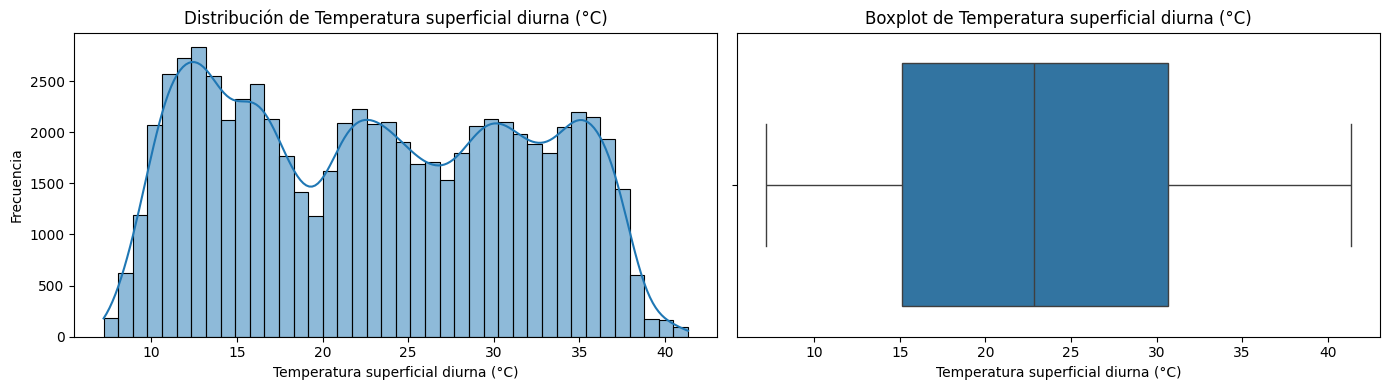

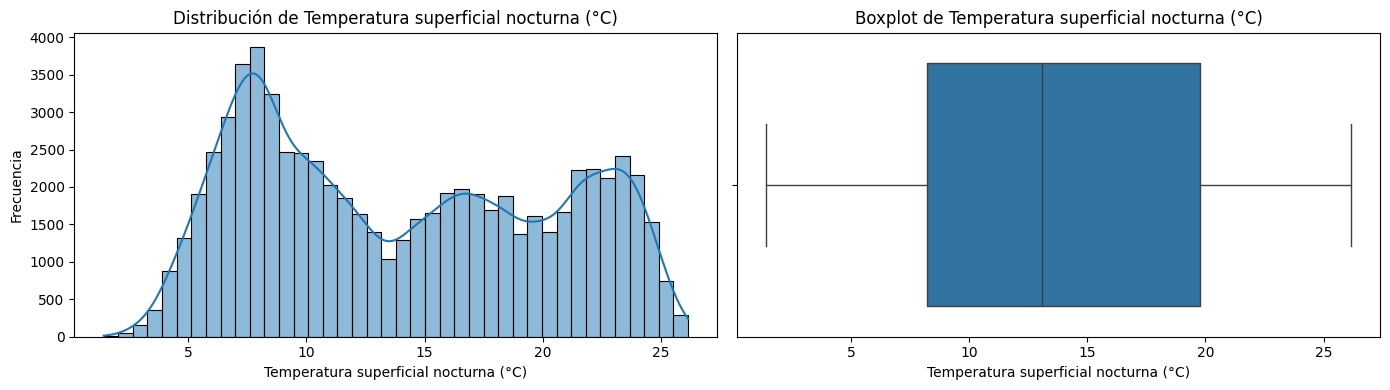

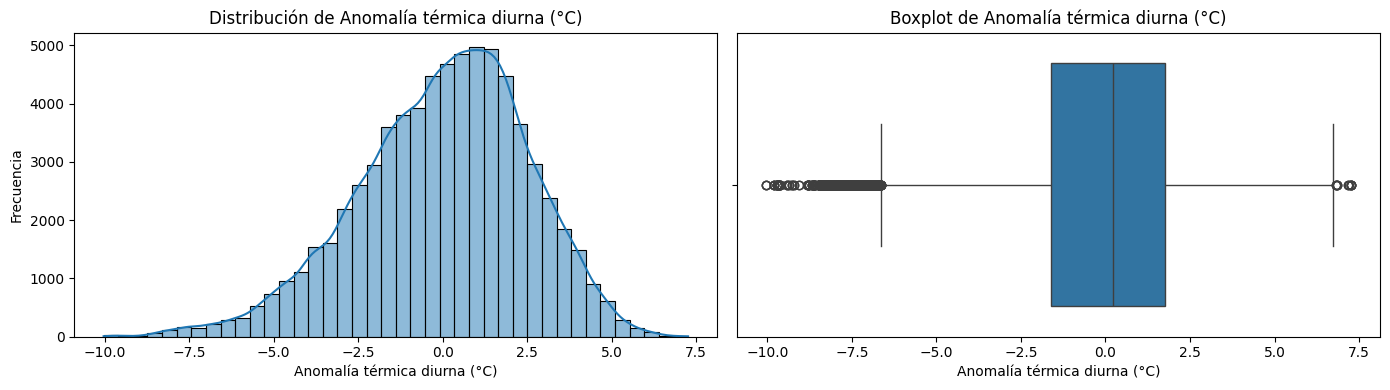

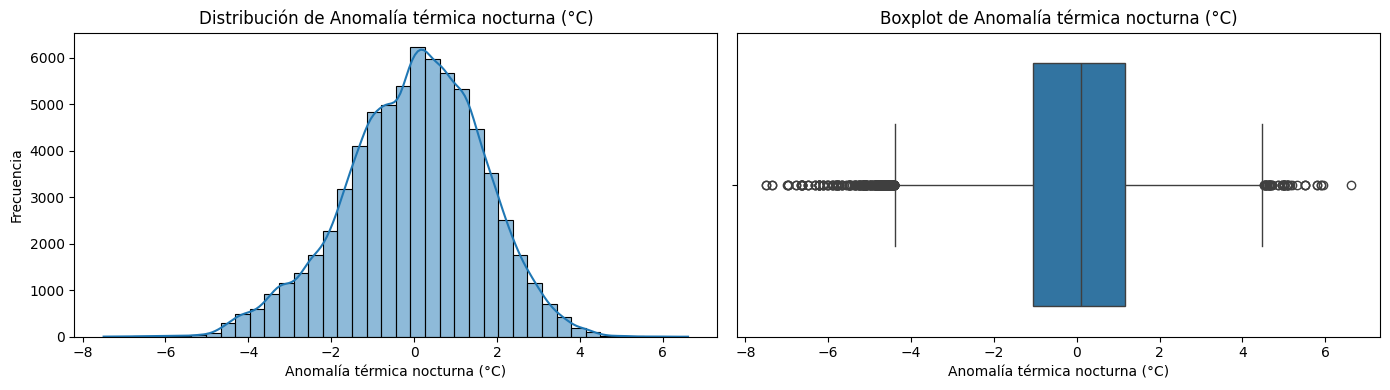

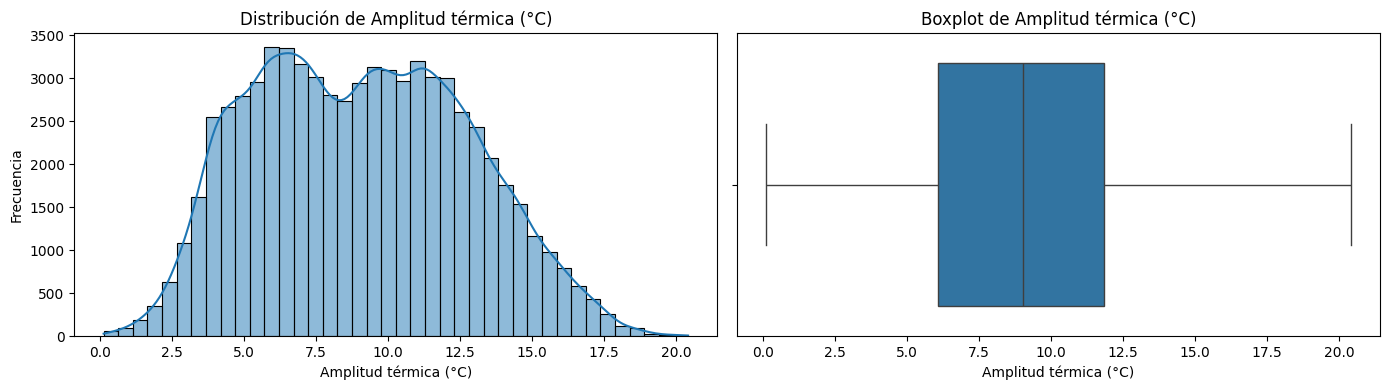

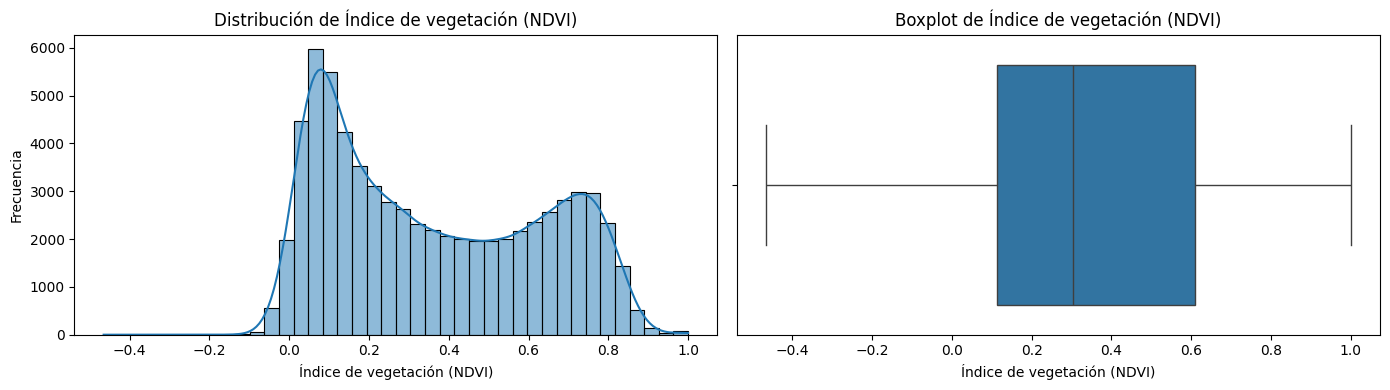

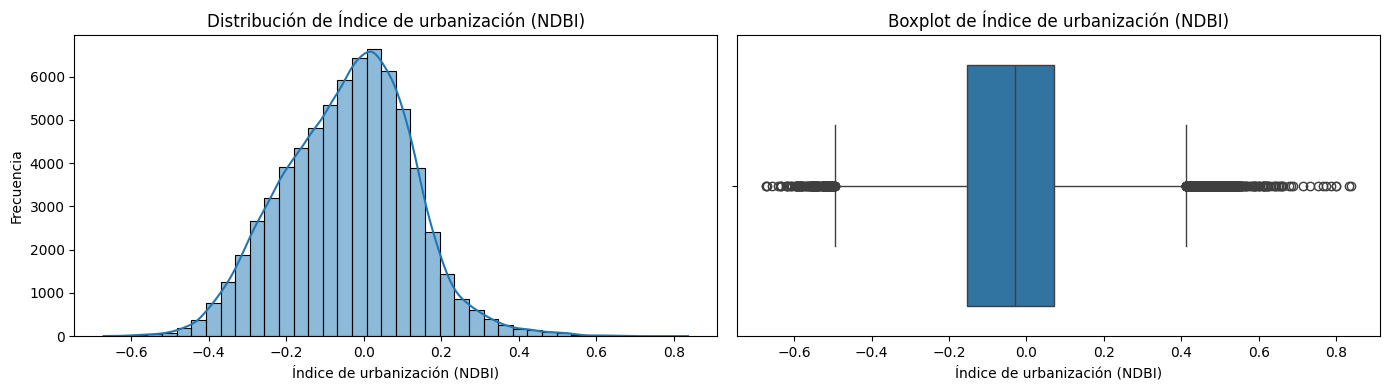

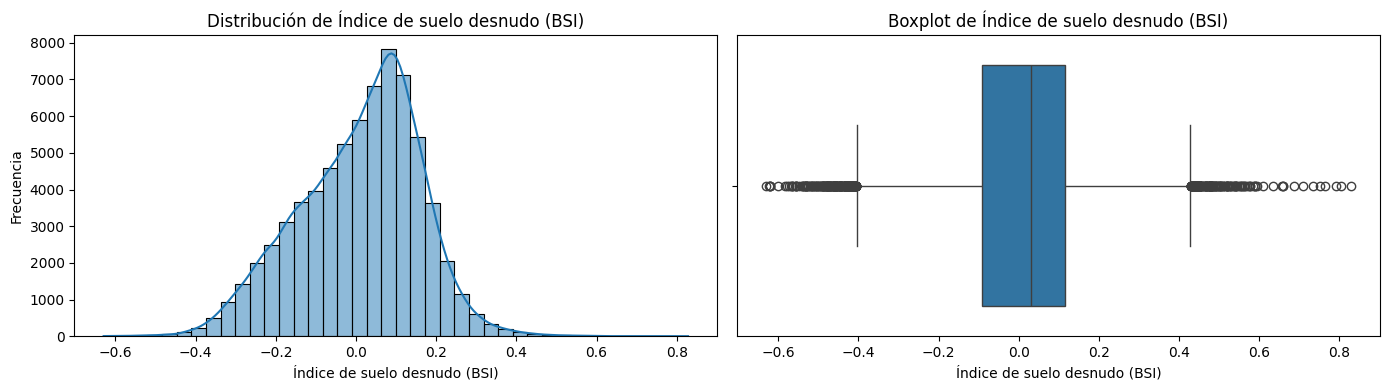

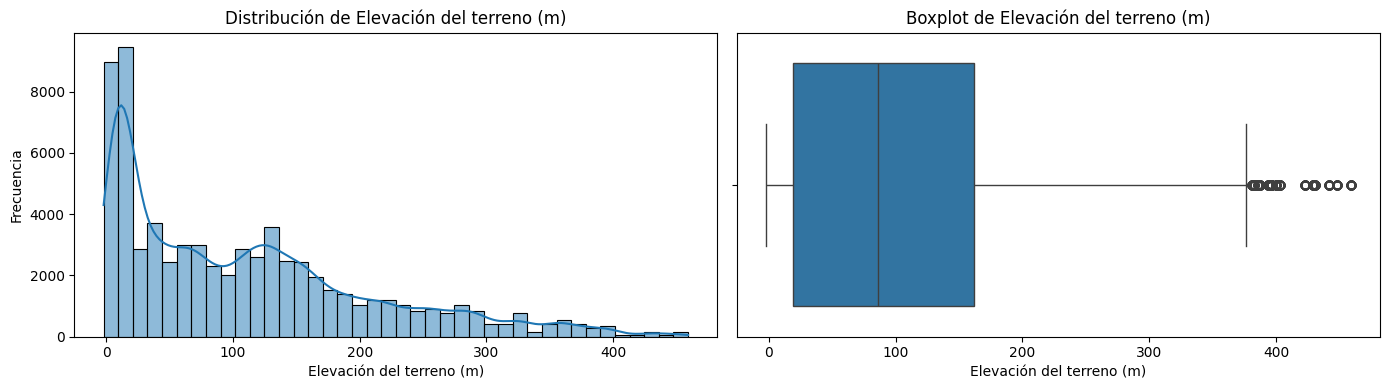

In [28]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ============================================================

# Visualizamos la distribución y posibles outliers
# de las variables numéricas más relevantes para el análisis UHI.

cols_num = [
    'lst_day_c',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_night_anomaly',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'bsi',
    'elevation'
]

# Diccionario de nombres más descriptivos para los gráficos

pretty_names = {
    'lst_day_c': 'Temperatura superficial diurna (°C)',
    'lst_night_c': 'Temperatura superficial nocturna (°C)',
    'lst_day_anomaly': 'Anomalía térmica diurna (°C)',
    'lst_night_anomaly': 'Anomalía térmica nocturna (°C)',
    'thermal_amplitude': 'Amplitud térmica (°C)',
    'ndvi': 'Índice de vegetación (NDVI)',
    'ndbi': 'Índice de urbanización (NDBI)',
    'bsi': 'Índice de suelo desnudo (BSI)',
    'elevation': 'Elevación del terreno (m)'
}

for col in cols_num:

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 4)
    )

    # Nombre bonito de la variable
    pretty_col = pretty_names[col]

    # Histograma
    sns.histplot(
        df_bcn[col],
        bins=40,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f'Distribución de {pretty_col}')
    axes[0].set_xlabel(pretty_col)
    axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(
        x=df_bcn[col],
        ax=axes[1]
    )

    axes[1].set_title(f'Boxplot de {pretty_col}')
    axes[1].set_xlabel(pretty_col)

    plt.tight_layout()
    plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

La temperatura superficial diurna presenta una distribución multimodal, lo que sugiere la existencia de distintos comportamientos térmicos asociados a estaciones del año, características urbanas y condiciones ambientales diferentes dentro del área de estudio.

El rango térmico observado resulta coherente para un entorno mediterráneo como Barcelona, con temperaturas superficiales que oscilan aproximadamente entre 7 °C y 41 °C.

Además, el boxplot no muestra valores extremos anómalos ni outliers severos, lo que aporta confianza sobre la calidad y consistencia de los datos utilizados en el análisis.

La dispersión observada indica una elevada variabilidad térmica espacial y temporal, aspecto especialmente relevante para el estudio del fenómeno Urban Heat Island (UHI).

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Análisis univariable de variables categóricas**

</div>

In [ ]:
# ============================================================
# VARIABLES CATEGÓRICAS
# ============================================================

# Revisamos las variables categóricas y los valores disponibles en cada una.

cat_vars = [
    'season',
    'uhi_risk'
]

cat_summary = pd.DataFrame({
    'variable': cat_vars,
    'n_unique_values': [df_bcn[col].nunique() for col in cat_vars],
    'values': [", ".join(map(str, sorted(df_bcn[col].dropna().unique()))) for col in cat_vars]
})

cat_summary

,variable,n_unique_values,values
0,season,4,"autumn, spring, summer, winter"
1,uhi_risk,2,"0, 1"


In [32]:
# ============================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

# Revisamos el número de registros pertenecientes a cada clase
# de la variable objetivo uhi_risk.

# 0 -> no risk
# 1 -> risk

df_bcn['uhi_risk'].value_counts()

uhi_risk
1    36621
0    33062
Name: count, dtype: int64

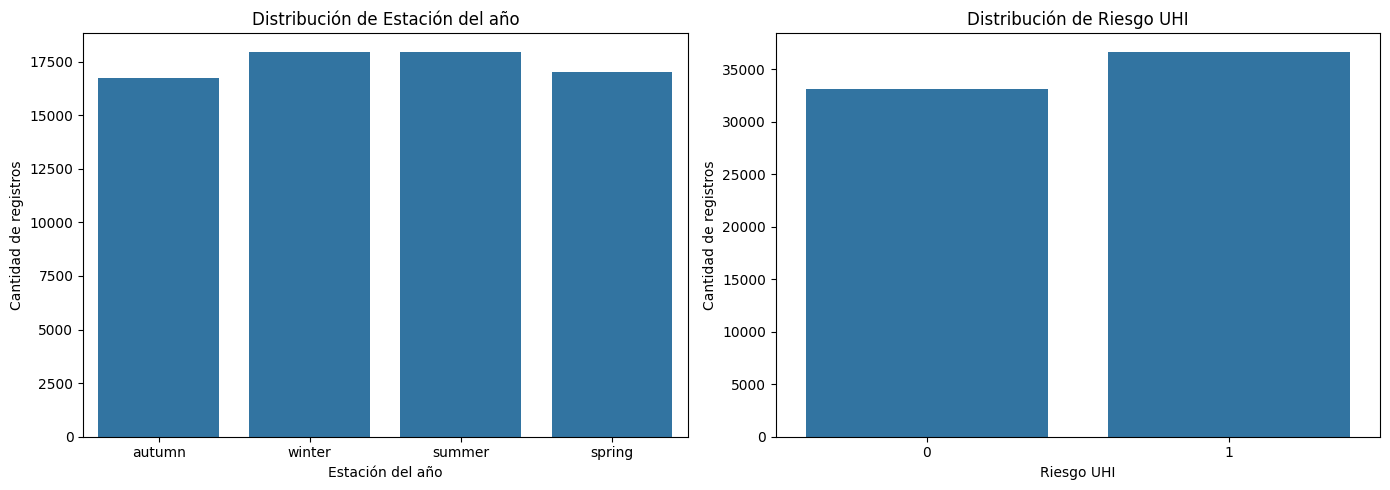

In [33]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

# Visualizamos la distribución de las variables categóricas principales del dataset.

cat_cols = [
    'season',
    'uhi_risk'
]

# Nombres descriptivos para los gráficos

pretty_cat_names = {
    'season': 'Estación del año',
    'uhi_risk': 'Riesgo UHI'
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df_bcn,
        x=col,
        ax=axes[i]
    )

    # Nombre bonito
    pretty_col = pretty_cat_names[col]

    axes[i].set_title(f'Distribución de {pretty_col}')
    axes[i].set_xlabel(pretty_col)
    axes[i].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

Las estaciones del año presentan una distribución bastante equilibrada, lo que indica que el dataset mantiene una representación temporal consistente a lo largo del período analizado.

La variable objetivo `uhi_risk` también presenta una distribución relativamente balanceada entre las clases *risk* y *no risk*, lo cual resulta favorable para el entrenamiento de modelos de clasificación.

Este equilibrio se debe a que la variable fue construida utilizando anomalías térmicas nocturnas respecto a la media mensual, considerando como zonas de riesgo aquellas con temperaturas nocturnas superiores al comportamiento esperado.

En conjunto, estas distribuciones reducen el riesgo de sesgo hacia una clase dominante y favorecen un aprendizaje más estable por parte de los modelos predictivos.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **variables numericas vs uhi_risk**

</div>

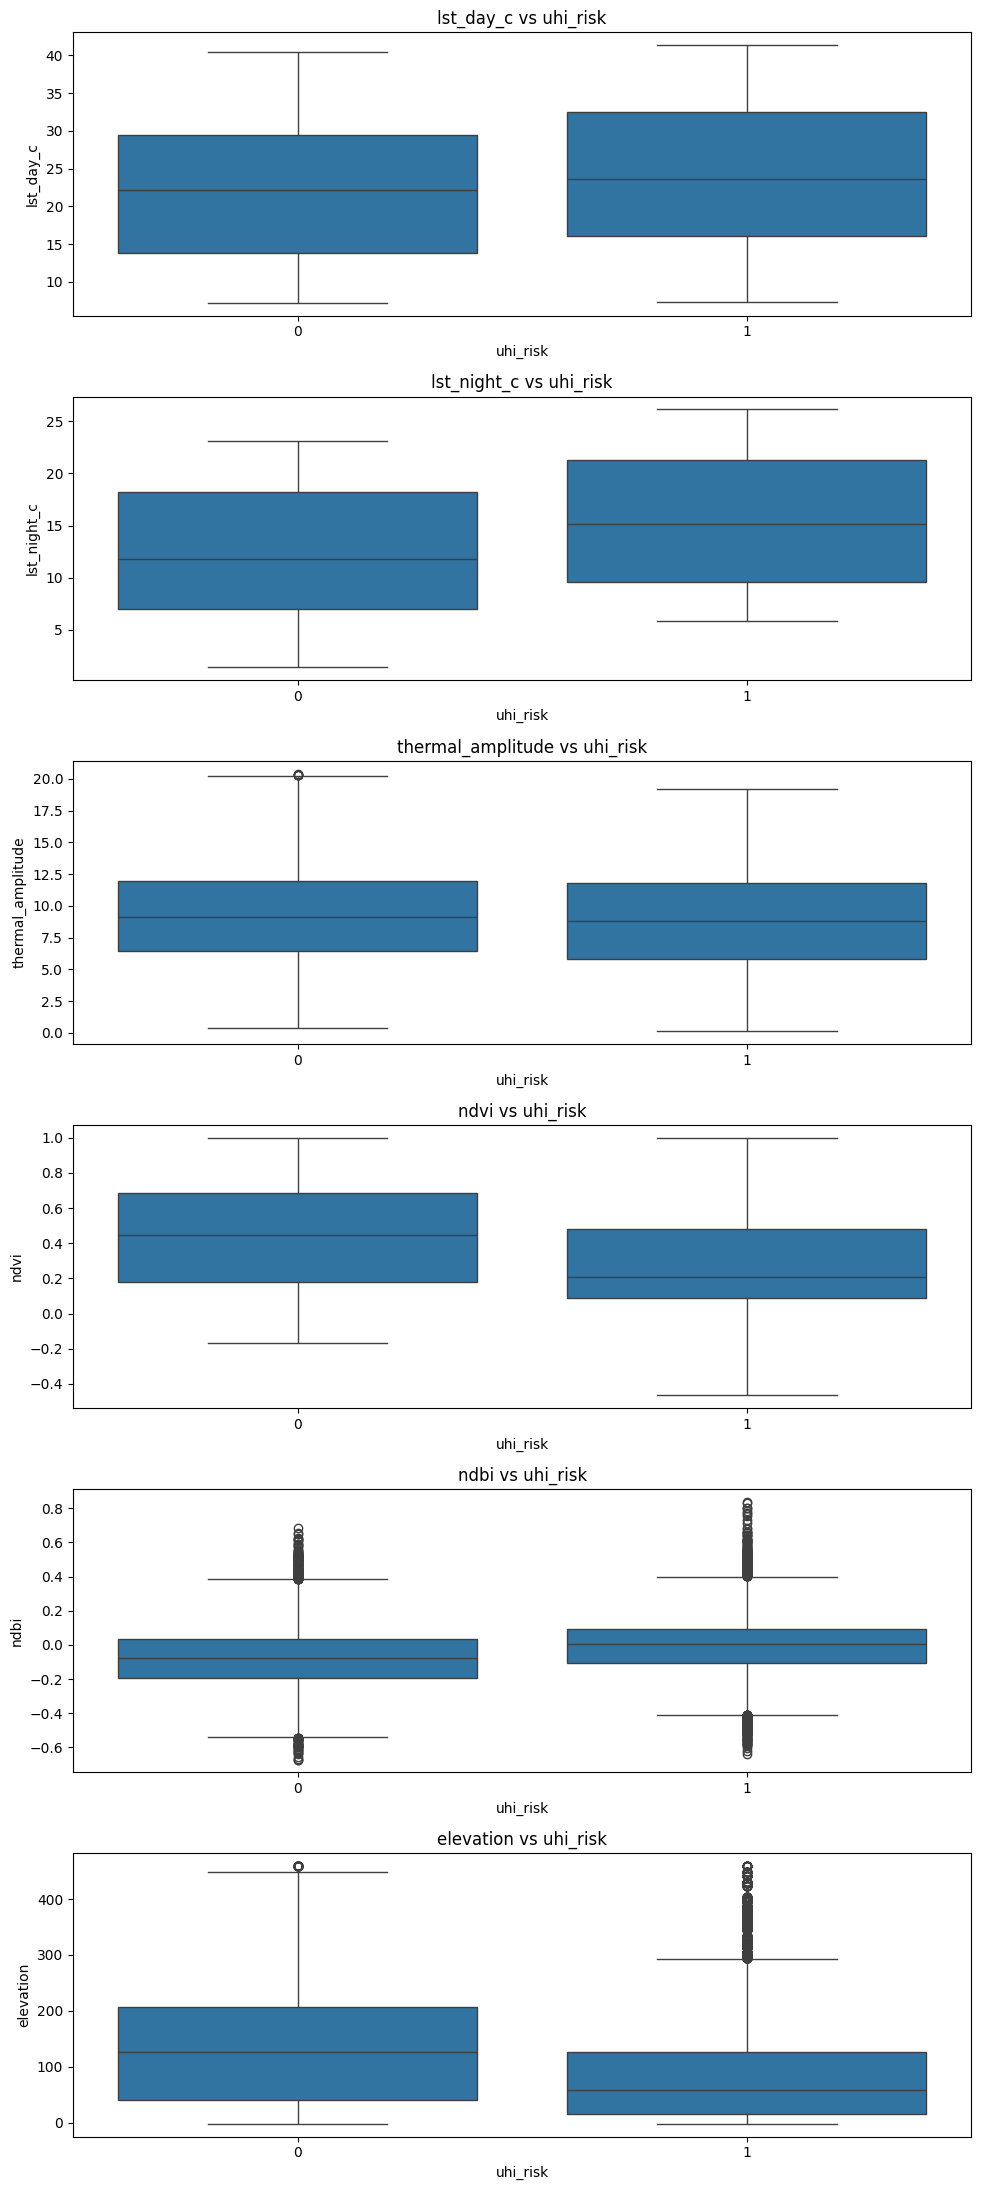

In [24]:
# ============================================================
# NUMERICAL VARIABLES VS UHI RISK
# ============================================================

# Analizamos cómo cambian las variables numéricas según el nivel de riesgo UHI.

num_vars = [
    'lst_day_c',
    'lst_night_c',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'elevation'
]

fig, axes = plt.subplots(len(num_vars), 1, figsize=(10, 22))

for i, col in enumerate(num_vars):

    sns.boxplot(
        data=df_bcn,
        x='uhi_risk',
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs uhi_risk')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación variables numericas vs uhi_risk**

Las variables relacionadas con temperatura nocturna (`lst_night_c`) y cobertura (`ndvi`) urbana muestran una relación más clara con el riesgo UHI.

En particular, `lst_night_c` aumenta progresivamente entre las categorías low, medium y high, mientras que `ndvi` presenta una relación inversa, indicando menor vegetación en zonas de mayor riesgo térmico.

Por otro lado, variables como `lst_day_c` y `thermal_amplitude` muestran distribuciones más solapadas entre categorías, lo que sugiere una menor capacidad discriminatoria individual respecto al riesgo UHI.

Estos resultados refuerzan la decisión de construir la variable objetivo utilizando la anomalía térmica nocturna como principal indicador del fenómeno Urban Heat Island.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **variables categoricas vs uhi_risk**

</div>

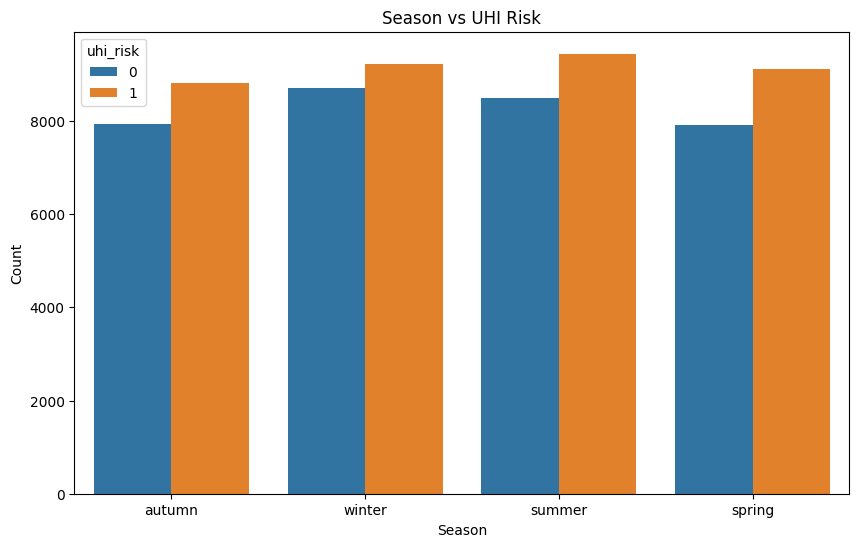

In [25]:
# ============================================================
# CATEGORICAL VARIABLES VS UHI RISK
# ============================================================

# Analizamos cómo se distribuye el riesgo UHI según la estación del año.

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_bcn,
    x='season',
    hue='uhi_risk'
)

plt.title('Season vs UHI Risk')
plt.xlabel('Season')
plt.ylabel('Count')

plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación variable categoricas vs uhi_risk**

La distribución del riesgo UHI varía según la estación del año. 

Aunque podría esperarse una mayor concentración de riesgo alto en verano, los resultados muestran una distribución relativamente equilibrada, mientras que primavera presenta una mayor cantidad de registros clasificados como `high`.

Esto sugiere que el riesgo UHI no depende únicamente de temperaturas elevadas, sino también de las diferencias térmicas relativas dentro de cada período analizado.

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Matriz de correlación**

Para el análisis de correlación se seleccionan únicamente las variables térmicas e índices espectrales más relevantes del dataset, evitando incluir identificadores, coordenadas o variables redundantes que podrían añadir ruido visual al mapa de correlación.

El objetivo es centrarse en aquellas variables con mayor interés climático y urbano para el estudio del fenómeno Urban Heat Island (UHI), facilitando la identificación de relaciones entre temperaturas, anomalías térmicas, vegetación y superficie urbanizada.

Además, la variable objetivo `uhi_risk` se codifica temporalmente a formato numérico (`low=0`, `medium=1`, `high=2`) con el único propósito de calcular correlaciones y analizar qué variables presentan una mayor relación con el nivel de riesgo UHI.

</div>

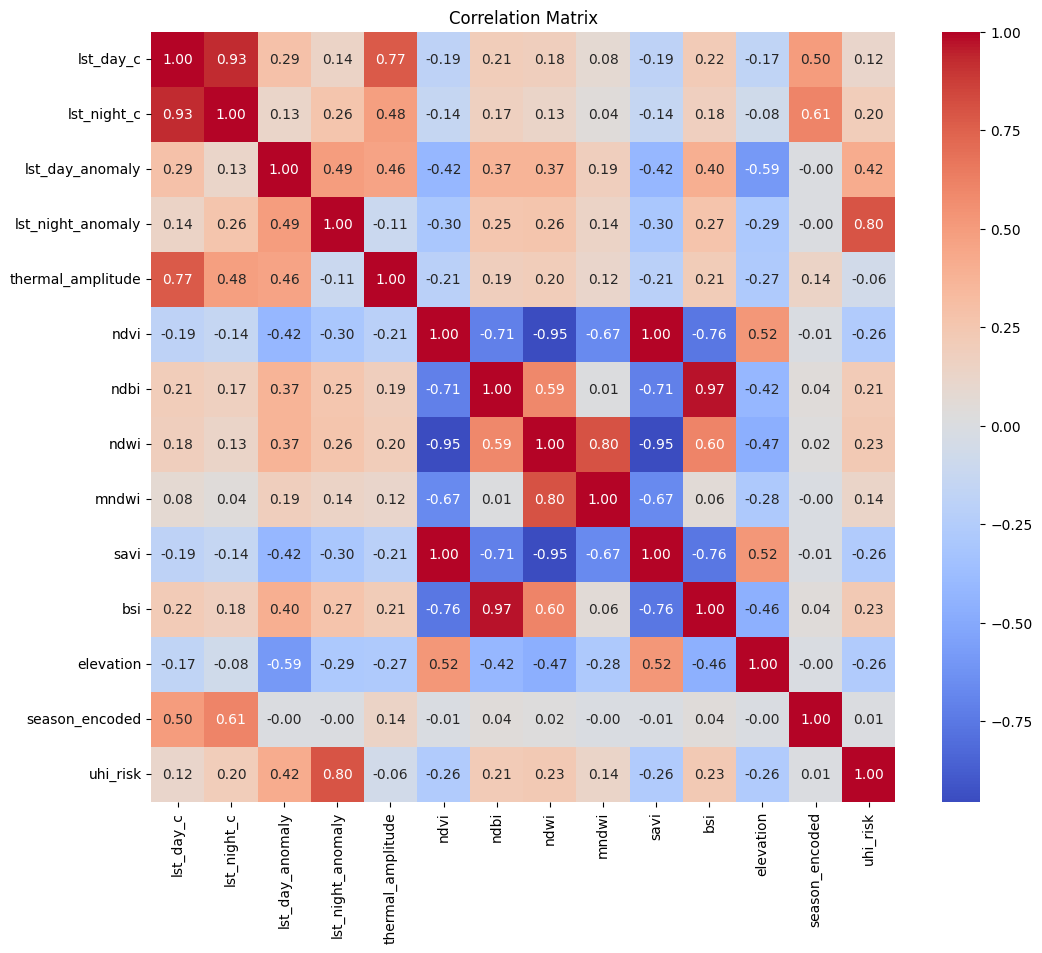

In [26]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

# Codificamos temporalmente las variables categóricas para analizar correlaciones.
# - season se codifica con ordinal encoding según orden climático.
# - uhi_risk ya es binaria (0 = no risk, 1 = risk), no requiere codificación adicional.

df_corr = df_bcn.copy()

df_corr['season_encoded'] = df_corr['season'].map({
    'winter': 0,
    'spring': 1,
    'summer': 2,
    'autumn': 3
})

# Seleccionamos variables relevantes para el análisis de correlación.

corr_vars = [
    'lst_day_c',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_night_anomaly',
    'thermal_amplitude',
    'ndvi',
    'ndbi',
    'ndwi',
    'mndwi',
    'savi',
    'bsi',
    'elevation',
    'season_encoded',
    'uhi_risk'
]

# Calculamos matriz de correlación.

corr_matrix = df_corr[corr_vars].corr()

# Visualizamos el mapa de correlación.

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Variables más relevantes respecto a `uhi_risk`**

| Variable | Correlación con `uhi_risk_encoded` | Interpretación |
|---|---|---|
| `lst_night_c_anomaly` | **0.89** | Variable más importante. Representa directamente la retención anómala de calor nocturno asociada al fenómeno UHI. |
| `lst_day_c_anomaly` | **0.45** | El comportamiento térmico diurno también influye en el riesgo UHI. |
| `ndvi` | **-0.30** | Más vegetación → menor riesgo UHI. |
| `savi` | **-0.30** | Refuerza la misma idea observada en NDVI. |
| `ndwi` | **0.26** | Puede estar capturando humedad o determinadas superficies urbanas. |
| `bsi` | **0.26** | Más suelo construido/desnudo → mayor riesgo UHI. |
| `lst_night_c` | **0.22** | Temperaturas nocturnas elevadas → mayor persistencia del calor urbano. |

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Posibles variables redundantes detectadas**

La matriz de correlación también permite identificar variables con correlaciones extremadamente altas entre sí, lo que puede indicar redundancia de información. Este análisis será importante durante la fase de modelado para reducir multicolinealidad, simplificar el conjunto de features y mejorar la interpretabilidad del modelo.

| Variables | Correlación | Motivo de posible redundancia |
|---|---|---|
| `ndvi` ↔ `savi` | **1.00** | Ambas variables representan cobertura vegetal y aportan prácticamente la misma información. |
| `ndvi` ↔ `ndwi` | **-0.95** | Aunque representan fenómenos distintos (vegetación y humedad), muestran comportamientos muy similares en el dataset. |
| `lst_day_c` ↔ `lst_night_c` | **0.93** | Las temperaturas diurnas y nocturnas tienden a evolucionar conjuntamente en muchas zonas urbanas. |
| `ndbi` ↔ `bsi` | **0.97** | Ambas variables están relacionadas con superficies urbanas o suelo desnudo, mostrando patrones muy similares. |

<br>

Aun así, una correlación alta no implica automáticamente que una variable deba eliminarse. También es importante considerar si las variables representan fenómenos físicos distintos y el impacto real que tienen sobre el rendimiento del modelo.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Ingenieria de caracteristicas**

</div>

In [ ]:
# ============================================================
# FEATURE SELECTION
# ============================================================

# Eliminamos variables que no aportan valor al modelado:
# - point_id: identificador único sin significado físico.
# - city: contiene un único valor ('Barcelona') y no aporta variabilidad.
# - date: ya fue descompuesta en variables temporales más útiles como month, year.

cols_drop = ['point_id', 'date']

df_bcn = df_bcn.drop(columns=cols_drop)

# Verificamos las columnas restantes
df_bcn.columns.tolist()

['latitude',
 'longitude',
 'elevation',
 'month',
 'year',
 'bsi',
 'mndwi',
 'nbr',
 'ndbi',
 'ndmi',
 'ndvi',
 'ndwi',
 'nir',
 'savi',
 'swir1',
 'swir2',
 'lst_day_c',
 'lst_night_c',
 'lst_day_anomaly',
 'lst_night_anomaly',
 'thermal_amplitude',
 'season',
 'uhi_risk']

In [48]:
# ============================================================
# REMOVING REDUNDANT VARIABLES
# ============================================================

# Eliminamos variables redundantes o auxiliares antes del modelado:
# - savi: altamente correlacionada con ndvi (correlación ≈ 1.00).
# - bsi: altamente correlacionada con ndbi (correlación ≈ 0.97).
# - uhi_risk_encoded: solo fue creada para el análisis de correlación.

redundant_features = [
    'savi',
    'bsi',
    'uhi_risk_encoded',
    'lst_night_anomaly',
    'lst_night_c',
    'lst_day_anomaly',
    'lst_day_c',
    'thermal_amplitude',
    'month',
    'year'
]

df_bcn = df_bcn.drop(
    columns=[c for c in redundant_features if c in df_bcn.columns]
)

df_bcn.columns.tolist()

['latitude',
 'longitude',
 'elevation',
 'mndwi',
 'nbr',
 'ndbi',
 'ndmi',
 'ndvi',
 'ndwi',
 'nir',
 'swir1',
 'swir2',
 'season',
 'uhi_risk']

In [50]:
# ============================================================
# SAVE CLEAN DATASET FOR MODELING
# ============================================================

# Guardamos el dataset procesado tras el EDA y feature engineering
# para utilizarlo posteriormente en el notebook de modelado.

df_bcn.to_csv('../data/processed/dataset_modeling.csv', index=False)